# Tema 2: Fundamentos físico-matemáticos de los algoritmos de optimización
En este tema se van a proceder a realizar 3 actividades guiadas de generación de números aleatorios, así como tres actividades de extensión y otras 2 actividades optativas:
- La primera actividad guiada consiste en la implementación de un generador congruencial de números aleatorios, así como la comprobación de resultados utilizando un histograma y la representación de $n_k(n_k-1)$ y la discusión de los resultados.
- Partiendo de $u\sim U[0,1]$, producir números según una distancia exponencial a continuación usando $\lambda = 3$ y representando los resultados con un histograma:
$$
p_x(x) = \lambda e^{-\lambda x}\; , \;\; x[0,1]
$$
- La última actividad guiada consiste en volver a generar números exponenciales gaussianos y enunciar los inconvenientes de este método.


Las librerías a emplear en los ejercicios de este segundo tema serán:
- matplotlib
- numpy
- math
- scipy

In [91]:
import matplotlib.pyplot as plt
import numpy as np
import math
from scipy.stats import norm

Establecemos los colores de las gráficas:

In [92]:
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "#1b0033",
    "axes.facecolor": "#1b0033",
    "axes.edgecolor": "#ff71ce",
    "axes.labelcolor": "#ff71ce",
    "xtick.color": "#01cdfe",
    "ytick.color": "#01cdfe",
    "grid.color": "#05ffa1",
    "text.color": "#ff71ce",
    "font.family": "monospace"
})

# Primera actividad guiada
Implementar un generador congruencial con:

a) $a = 9$, $b = 1$, $M = 1103$

b) $a = 1230$, $b = 1201$, $M = 1001$

c) Fibonacci: $a = 1$, $b = 1$, $\mu = 1$, $M = 10001$

Generar el histograma con $10^6$ números y representar $n_k(n_k-1)$. Discutir los resultados.

Para esto se va a hacer una función que sea posible aplicar tanto para el generador lineal congruencial como para el generador Fibonacci dependiendo de los parámetros dados a la función. Concretamente se darán los parámetros a, b, M y N para el método de generador congruencial lineal y, adicionalmente, c, mu, nu para el caso del generador Fibonacci. También se dará la opción de establecer los valores iniciales seed_1 y seed_2. Como respuesta, el generador proveera el array de números con valores entre 0 y 1 generados. A continuación la función a emplear para los cálculos del generador congruencial y Fibonacci respectivamente:
$$
n_k = \left(a \cdot n_{k-1} + b\right) \;\text{mod}\; M
$$
$$
n_k = \left(a \cdot n_{k-\mu} + b \cdot n_{k-\nu} + c\right) \;\text{mod}\; M
$$

In [93]:
def congruential_generator(a,b,M,N,c=None,mu=None,nu=None,seed_1=None,seed_2=None):
    n_k = []
    aux_n_k = []
    # Establecimiento de los valores iniciales en caso de no ser especificados en la función
    if seed_1 == None:
        seed_1 = 0
        seed_2 = 2

    # Generador congruencial lineal
    if nu != None:
        n_k.append(seed_1)
        n_k.append(seed_2)
        for i in range(N):
            n_k.append((a * n_k[i-1+mu] + b * n_k[i-1+nu] + c)%M)
        n_k = np.array(n_k)/M
    else:
    # Generador de fibonacci
        n_k.append(seed_1)
        for i in range(1,N):
            n_k.append((a * n_k[i-1] + b)%M)
        n_k = np.array(n_k)/M

    return n_k


section_a = congruential_generator(9,1,1103,10000)
section_b = congruential_generator(1230,1201,10001,10000)
section_c = congruential_generator(1,1,10001,10000,0,1,2)

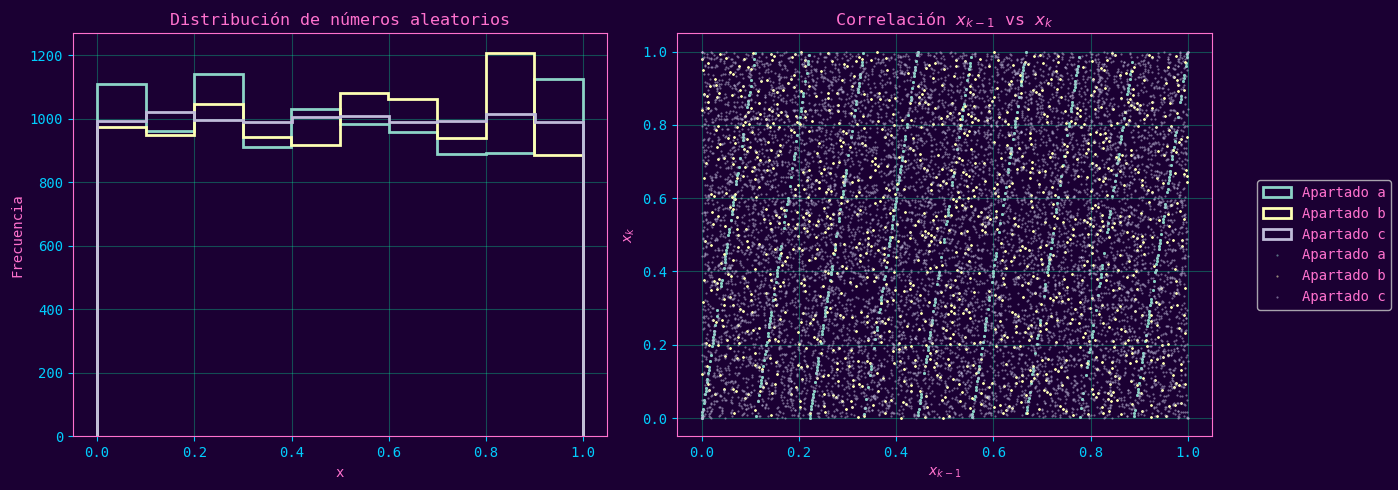

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax in axes:
    ax.grid(alpha=0.3)


# Histograma
axes[0].hist(
    section_a,
    histtype='step',
    lw=2,
    label='Apartado a'
)

axes[0].hist(
    section_b,
    histtype='step',
    lw=2,
    label='Apartado b'
)

axes[0].hist(
    section_c,
    histtype='step',
    lw=2,
    label='Apartado c'
)

axes[0].set_title('Distribución de números aleatorios')
axes[0].set_xlabel('x')
axes[0].set_ylabel('Frecuencia')

# Diagrama de correlación
axes[1].plot(
    section_a[:-1], section_a[1:],
    'o',
    ms=0.5,
    alpha=0.6,
    label='Apartado a'
)

axes[1].plot(
    section_b[:-1], section_b[1:],
    'o',
    ms=0.5,
    alpha=0.6,
    label='Apartado b'
)

axes[1].plot(
    section_c[:-1], section_c[1:],
    'o',
    ms=0.5,
    alpha=0.6,
    label='Apartado c'
)

axes[1].set_title(r'Correlación $x_{k-1}$ vs $x_k$')
axes[1].set_xlabel(r'$x_{k-1}$')
axes[1].set_ylabel(r'$x_k$')

# ===== Leyenda común =====
fig.legend(
    loc='center right',
    fontsize=10,
    frameon=True
)

# Espacio para la leyenda
plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


Los resultados obtenidos para los apartados varían en calidad pero fluctuan en torno a los 1000 números aleatorios generados para cada rango de 0.1 entre 0 y 10. Podemos hacer las siguientes observaciones:
- En el histograma generado se puede apreciar que para el caso del apartado a existen variaciones significativas entre cada uno de los tramos evaluados, significando esto una inconsistencia significativa de generación de números en comparación con los otros dos métodos. 
- Sin embargo, la mayor variación entre números aleatorios generados de un rango y de otro se puede achacar a los valores entre 0.8-0.9 y 0.9 1.0 para el apartado b. A pesar de esta variación significativa, los números generados para cada tramo evaluado oscilan en torno a los 1000 de manera más consistente para este apartado que para el anterior. 
- Como último comentario del histograma podemos señalar que en el caso de los números aleatorios generados en el apartado c, estos son los más uniformemente distribuidos, oscilando en torno a los 10000 para los 10 rangos evaluados.
- En cuanto a la gráfica a la derecha, podemos ver de nuevo una mejora progresiva en los métodos de los apartados a, b y c a la hora de señalar la correlación entre un número aleatorio y el siguiente que ha sido generado a partir de él. En el caso del método a hay una dependencia lineal significativa entre los números generados común a los generadores congruenciales lineales debido a la ecuación empleada para su generación. 
- En el caso del apartado b se puede apreciar una mejora de la dispersión de los puntos, estando estos distribuidos de mejor manera, pero siguiendo la tendencia que tan clara era en el caso del apartado a.
- Por último, el apartado c, al ser un generador de Fibonacci, mejora significativamente los dos métodos anteriores, dando una distribución significativamente uniforme de números aleatorios.

# Segunda actividad guiada 
En este ejercicio se va a llevar a cabo el método de la transformada inversa. 

## Primer apartado
Lo que se busca es que a partir de números $u\sim U[0,1]$ producir números según una distribución exponencial:
$$
p_x(x) = \lambda e^{-\lambda x}, \; x\in [0,1]
$$

Utilizar e.g. $\lambda = 3$ y representar el histograma.

Para poder llevar a cabo este ejercicio en primer lugar se ha de tomar la ecuación previamente mencionada y se ha de emplear la ecuación:
$$
F_x(x) \equiv \int_{x_{min}}^x p_x(x') dx'
$$
con el fin de obtener la Función de Distribución Acumulada, para posteriormente igualar los valores y obtener el valor adecuado a representar. 

En nuestro caso, los cálculos realizados dan como resultado:
$$
F(x) = 1 - e^{-\lambda x}
$$
$$
u = 1 - e^{-\lambda x} \Rightarrow x = - \frac{1}{\lambda} ln(1-u)
$$
Esta última ecuación se puede simplificar a:
$$
x = - \frac{ln(u)}{\lambda}
$$
A esta ecuación se le introduciran números aleatorios generados entre 0 y 1 con la librería "random" para posteriormente obtener números aleatorios con una tendencia gaussiana.

In [95]:
def random_coordinate_generator(number_ammount):
    x = []
    y = []
    x = np.random.rand(number_ammount)
    y = np.random.rand(number_ammount)
    return x,y

In [96]:
def random_exponential_number_generator(x,lam):
    x_exponential = []
    x_exponential = -np.log(x)/ lam
    return x_exponential

lam = 3
x,y = random_coordinate_generator(1000000)
x_exponential = random_exponential_number_generator(x,lam)

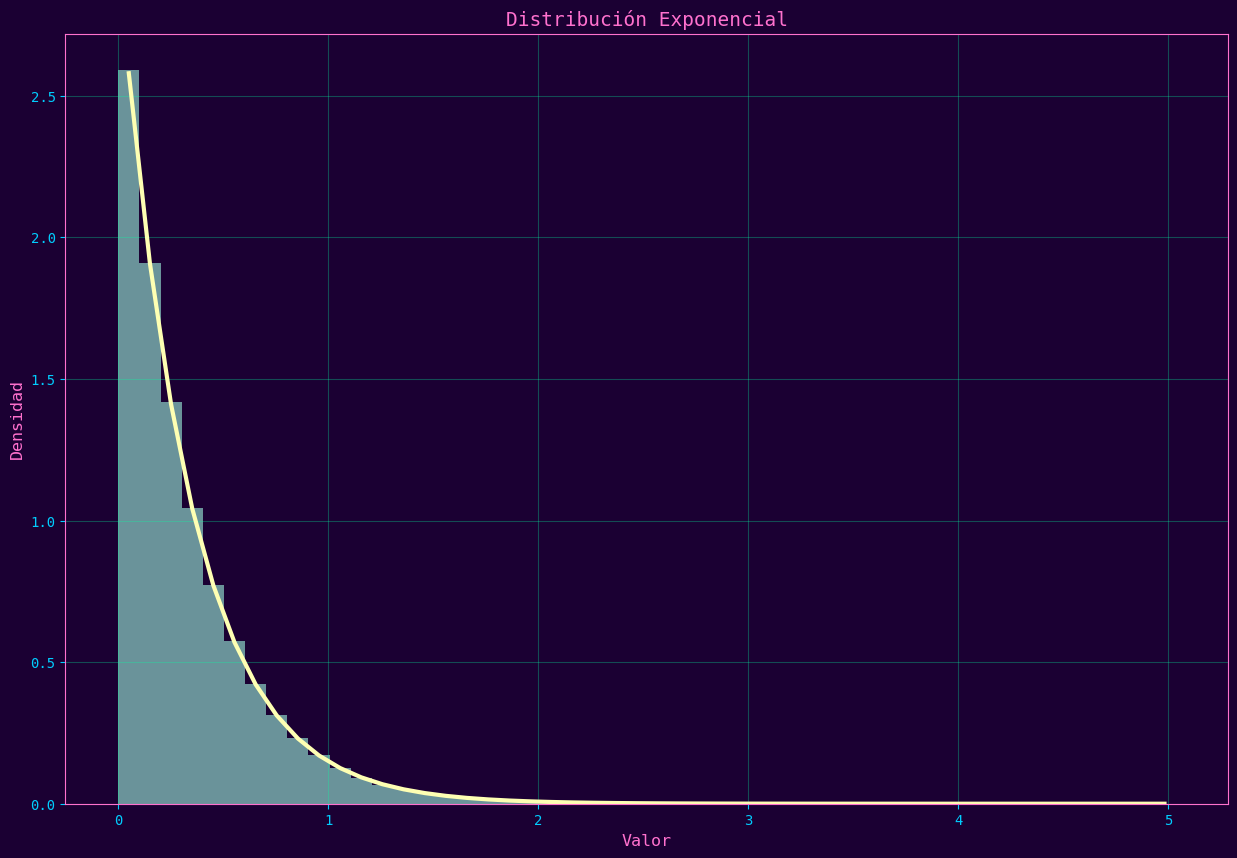

In [97]:
plt.figure(figsize=(15, 10))

counts, bins, patches = plt.hist(
x_exponential,
    bins=50,
    density=True,
    alpha=0.7,
    label="Simulación",
)

midpoints = (bins[:-1]+bins[1:])/2 # genera un array con los puntos medios de cada bin
plt.plot(
    midpoints,
    lam*np.exp(-lam*midpoints),
    linewidth=3,
    label="Teórica",
)

plt.title("Distribución Exponencial", fontsize=14)
plt.xlabel("Valor", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()


Se puede ver con la comparación con la gráfica de la función exponencial solapada que el resultado obtenido se adecúa muy bien al resultado esperado, siendo una bajada rápida al comienzo y procediendo a ser poco a poco menor cuando mayor es el número obtenido.

## Segundo apartado
También se pide aplicar este mismo procedimiento para la generación de números gaussianos. En este caso las ecuaciones que se van a utilizar para obtener los números gaussianos se han obtenido igual que en el caso anterior pero de una manera ligeramente más compleja debido a que se están generando números en dos dimensiones son:
$$
x = \sqrt{-2 \log{(u_1)}} \cos (2\pi \times u_2)
$$
$$
y = \sqrt{-2 \log{(u_1)}} \sin (2\pi \times u_2)
$$

NOTA: Número aleatorio gausiano es aquel que sigue una distribución en forma de campana de Gauss, a diferencia de la ditribución uniforme que se vio en el ejercicio anterior.

In [98]:
def random_gauss_coordinate_generator(x,y):
    x_gauss = []
    y_gauss = []
    x_gauss = np.sqrt(-2 * np.log(x)) * np.cos(2 * np.pi*y)
    y_gauss = np.sqrt(-2 * np.log(x)) * np.cos(2 * np.pi*y)
    return x_gauss, y_gauss

x_gauss, y_gauss = random_gauss_coordinate_generator(x,y)


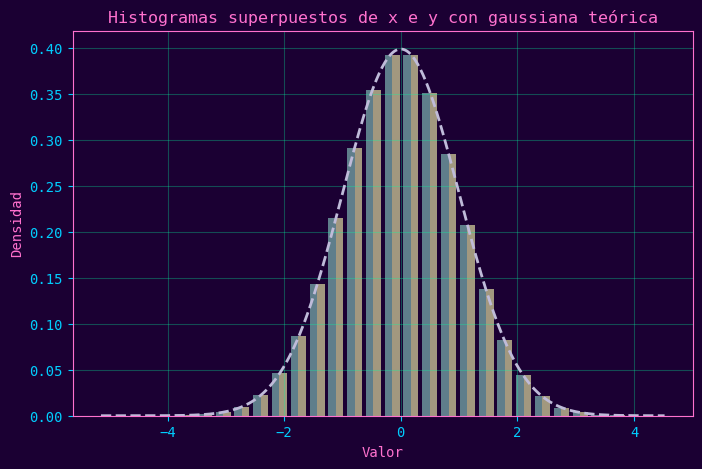

In [99]:
bins = np.linspace(x_gauss.min(), y_gauss.max(), 31)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    [x_gauss, y_gauss],
    bins=bins,
    density=True,
    alpha=0.6,
    label=["Datos x","Datos y"]
)

x_vals = np.linspace(bins[0], bins[-1], 400)
gauss = norm.pdf(x_vals, 0, 1)

ax.plot(
    x_vals,
    gauss,
    "--",
    linewidth=2,
    label="Gaussiana teórica N(0,1)"
)

ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.set_title(
    "Histogramas superpuestos de x e y con gaussiana teórica"
)

ax.grid(alpha=0.3)

plt.show()

Al igual que en el caso de la exponencial, la adecuación de los resultados se puede apreciar que se desvía ligeramente de la función gaussiana de referencia, pero que ofrece un muy buen resultado.

Cabe destacar que en el caso de la exponencial, los resultados comienzan a reflejar la influencia de dicha función en los números generados a partir del orden de 10000 números generados, mientras que en el caso de la gaussiana, este número es ligeramente superior.

# Tercera actividad guiada
En esta tercera actividad se nos pide calcular números exponenciales y gaussianos tal y como el apartado anterior pero en este caso hacerlo el método de aceptación rechazo. 

Este método consiste en 3 pasos que se iteran hasta obtener el resultado deseado. El primer paso es el de generar uniformemente puntos en un área situada entre $[x_{mín},x_{max}] \times [0,y_{max}]$. Una vez obtenidos todos los puntos se ha de proceder a comprobar si los puntos generados se encuentran por encima o por debajo de función con la cual se quiere comparar. Si son mayores se ha de rechazan y si son iguales o menores se aceptan. Estos pasos se repiten hasta obtener el resultado deseado.

Vamos a comenzar definiendo dos funciones, una para cada una de las funciones que vamos a evaluar, la exponencial y la gaussiana, en las cuales se introduzcan como parámetros las variables de dichas funciones y se devuelva el número resultante:

In [100]:
def exponential_function(lam,random_number):
    return lam*np.exp(-lam*random_number)

def gaussian_function(random_number):
    return (1/np.sqrt(2*np.pi))*np.exp(-(random_number**2)/2)

Vamos a generar números aleatorios, y a comprobar si se adecúan a las funciones definidas, no sin antes establecer los valores de lambda y de las condiciones de contorno:

In [101]:
lam = 2.
xmin_exponential = 0.
xmax_exponential = 5./lam
xmin_gaussian = -4.
xmax_gaussian = 4.
ymin_exponential = 0.
ymax_exponential = lam
ymin_gaussian = 0.
ymax_gaussian = 1./np.sqrt(2*np.pi)

In [102]:
random_number_ammount = 10**6
number_of_tries_exponential = 0

random_number_array_exponential = np.zeros(random_number_ammount)
for i in range(random_number_ammount):
    accepted = False
    while accepted == False:
        random_number_try = np.random.uniform(xmin_exponential,xmax_exponential)
        random_number_auxiliar = np.random.uniform(ymin_exponential,ymax_exponential)
        if random_number_auxiliar < exponential_function(lam,random_number_try): accepted = True
        number_of_tries_exponential = number_of_tries_exponential + 1
    random_number_array_exponential[i] = random_number_try

print(number_of_tries_exponential)

5034282


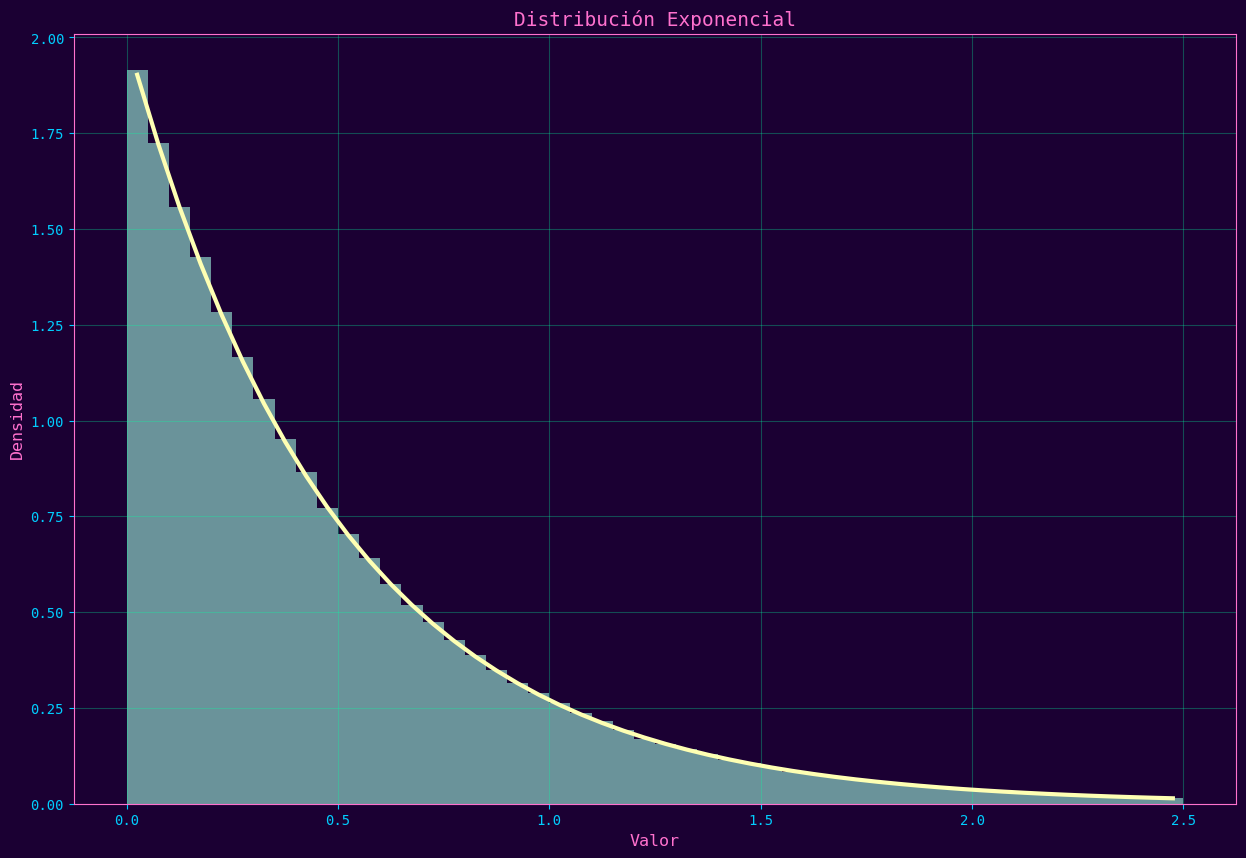

In [103]:
plt.figure(figsize=(15, 10))

counts, bins, patches = plt.hist(
    random_number_array_exponential,
    bins=50,
    density=True,
    alpha=0.7,
    label="Simulación",
)

midpoints = (bins[:-1]+bins[1:])/2 # genera un array con los puntos medios de cada bin
plt.plot(
    midpoints,
    lam*np.exp(-lam*midpoints),
    linewidth=3,
    label="Teórica",
)

plt.title("Distribución Exponencial", fontsize=14)
plt.xlabel("Valor", fontsize=12)
plt.ylabel("Densidad", fontsize=12)

plt.grid(True, alpha=0.3)

plt.show()


In [104]:
number_of_tries_gaussian = 0
random_number_array_gaussian = np.zeros(random_number_ammount)
for i in range(random_number_ammount):
    accepted = False
    while accepted == False:
        random_number_try = np.random.uniform(xmin_gaussian,xmax_gaussian)
        random_number_auxiliar = np.random.uniform(ymin_gaussian,ymax_gaussian)
        if random_number_auxiliar < gaussian_function(random_number_try): accepted = True
        number_of_tries_gaussian = number_of_tries_gaussian + 1
    random_number_array_gaussian[i] = random_number_try

print(number_of_tries_gaussian)

3195179


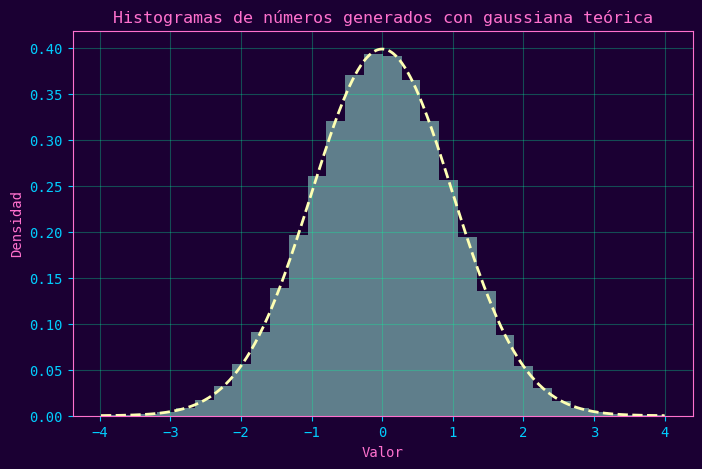

In [105]:
bins = np.linspace(random_number_array_gaussian.min(), random_number_array_gaussian.max(), 31)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    random_number_array_gaussian,
    bins=bins,
    density=True,
    alpha=0.6,
    label="Datos generados"
)

x_vals = np.linspace(bins[0], bins[-1], 400)
gauss = norm.pdf(x_vals, 0, 1)

ax.plot(
    x_vals,
    gauss,
    "--",
    linewidth=2,
    label="Gaussiana teórica"
)

ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
ax.set_title(
    "Histogramas de números generados con gaussiana teórica",
)

ax.grid(alpha=0.3)

plt.show()

En este método aplicado de nuevo a las funciones exponencial y gaussiana se puede ver como los resultados obtenidos son adecuados y se relacionan con las funciones de referencia con un número de valores generados superior a los 10000, pero se obtienen mejores resultados con un número de números mayor.

Comparando este método de aceptación rechazo con el método de transformada inversa se puede ver:
- A simple vista, se necesita un mayor número de valores a evaluar para poder generar un resultado adecuado en comparación al método de transformada inversa, ya que esta refleja unos buenos resultados a partir de los 10000 números, mientras que en el caso del método de aceptación rechazo, este número ha de ser mayor.
- En el caso del método de aceptación rechazo, se necesita generar un número de números aleatorios mayor al que se va a obtener como resultado debido a que se está rechazando una cantidad de ellos debido a que no se adecúan a los requerimientos establecidos. En el caso de la transformada inversa, todos los números son aceptados.
- Cabe mencionar sobre el método de aceptación rechazo que no requiere de cálculos adicionales, al contrario del método de la transformada inversa.
- En el caso del método de la transformada inversa, para el caso de querer obtener 100000 de números, el tiempo de ejecución es de 0.0 segundos para ambos cálculos, mientras que en el caso de la exponencial y la gaussiana para el método de aceptación rechazo es de 13.7 y 10.8 segundos respectivamente. Por lo tanto se puede concluir que el método de aceptación rechazo es significativamente peor en cuando a tiempo de ejecución que el método de la tranformada inversa.